In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.regression.neural_regression import NeuralRegressor
from src.classification.neural_classification import NeuralClassifier
import src.utils.function_collections as fc

rng = np.random.default_rng(519)

## Regression ##

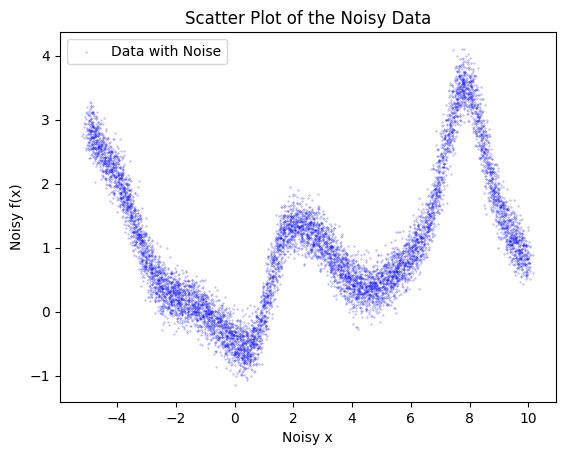

In [2]:
def f(x):
    return (-1 + x**2) / (x**2 + 2.3) * np.log(np.sin(np.sqrt(2)*x)**2 + 3) * np.exp(np.sin(x))

N_TRAIN = 9000
N_TEST = 1000
x_values_train = rng.uniform(-5, 10, N_TRAIN)
y_values_train = f(x_values_train)
x_values_train = x_values_train + rng.normal(0, 0.1, N_TRAIN)
y_values_train = y_values_train + rng.normal(0, 0.2, N_TRAIN)
x_values_test = rng.uniform(-5, 10, N_TEST)
y_values_test = f(x_values_test)
x_values_test = x_values_test + rng.normal(0, 0.1, N_TEST)
y_values_test = y_values_test + rng.normal(0, 0.2, N_TEST)
plt.scatter(x_values_train, y_values_train,
            color='blue', label='Data with Noise', s=0.1, alpha=0.5)
plt.xlabel('Noisy x')
plt.ylabel('Noisy f(x)')
plt.title('Scatter Plot of the Noisy Data')
plt.legend()
plt.show()

In [3]:
nn_regression = NeuralRegressor(1, 1, [10, 10], fc.leaky_logistic)
x_train = x_values_train.reshape(-1, 1)
y_train = y_values_train.reshape(-1, 1)
training_loss, validation_loss = nn_regression.train_model(x_train, y_train, 1000, 500, 0.01, 0.25)

Test loss: 0.024252873546490226


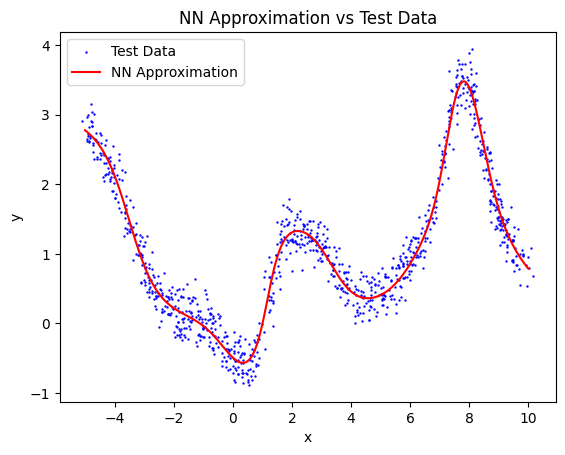

In [4]:
# Compute the test lost
y_test_pred = nn_regression.predict(x_values_test.reshape(-1, 1))
test_loss = nn_regression.compute_loss(
    y_values_test.reshape(-1, 1), y_test_pred)
print('Test loss:', test_loss)

# Plot the results
x_range = np.linspace(-5, 10, 1000).reshape(-1, 1)
y_pred_range = nn_regression.predict(x_range)
plt.scatter(x_values_test, y_values_test,
            color='blue', label='Test Data', s=0.5)
plt.plot(x_range, y_pred_range, color='red', label='NN Approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.title('NN Approximation vs Test Data')
plt.legend()
plt.show()

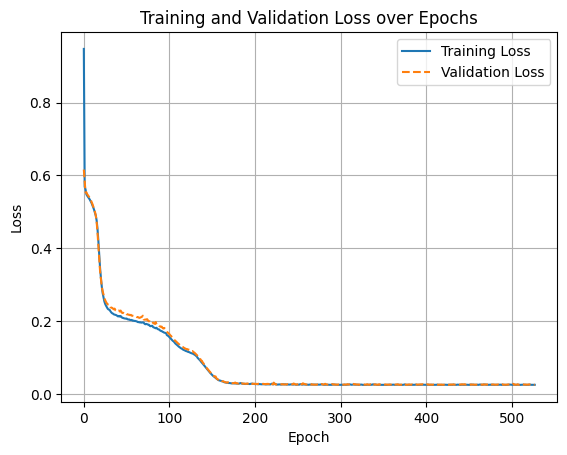

In [5]:
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss', linestyle='--')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

## Classification ##

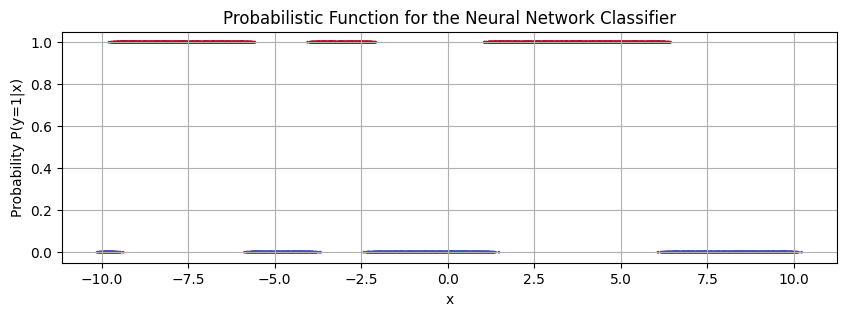

In [6]:
decision_boundaries = [-9.6, -5.7, -3.9, -2.2, 1.2, 6.3, 8.9]
def assign_label(x):
    for i in range(0, len(decision_boundaries), 2):
        if i + 1 < len(decision_boundaries) and decision_boundaries[i] < x < decision_boundaries[i + 1]:
            return 1
    return 0

N_TRAIN = 9000
N_TEST = 1000
data_train = rng.uniform(-10, 10, N_TRAIN)
labels_train = np.array([assign_label(x) for x in data_train])
data_train = data_train + rng.normal(0, 0.1, N_TRAIN)
data_test = rng.uniform(-10, 10, N_TEST)
labels_test = np.array([assign_label(x) for x in data_test])
data_test = data_test + rng.normal(0, 0.1, N_TEST)

plt.figure(figsize=(10, 3))
plt.scatter(data_train, labels_train, label='Training data', c=labels_train, cmap='coolwarm', s=1)
plt.xlabel('x')
plt.ylabel('Probability P(y=1|x)')
plt.title('Probabilistic Function for the Neural Network Classifier')
plt.grid(True)
plt.show()

In [7]:
classsify_activation_func = fc.leaky_tanh
classify_nn = NeuralClassifier(1, 2, [10, 10], fc.leaky_tanh)
classify_x_train = data_train.reshape(-1, 1)
classify_y_train = labels_train
classify_training_losses, classify_validation_losses = classify_nn.train_model_with_labels(classify_x_train, classify_y_train, 2500, 500, 0.01, 0.25)

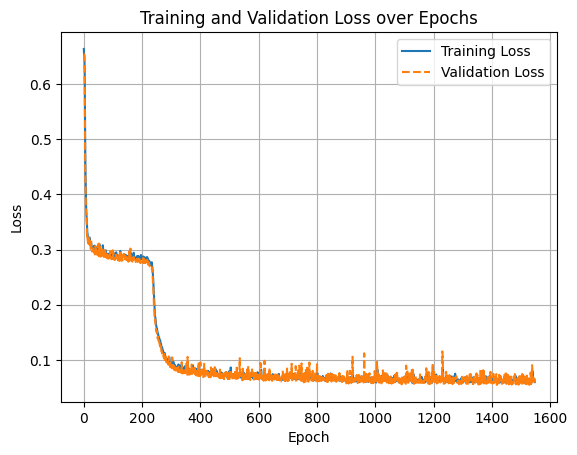

In [8]:
# plot the loss
plt.plot(classify_training_losses, label='Training Loss')
plt.plot(classify_validation_losses, label='Validation Loss', linestyle='--')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

Test loss: 0.06194262858187327
Accuracy: 0.969


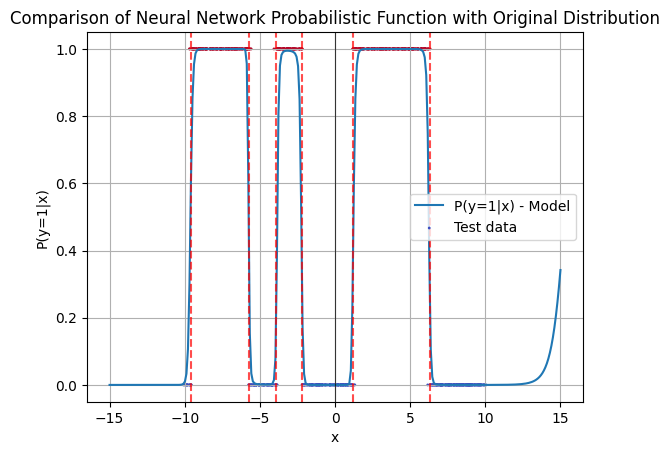

In [9]:
# Compute the test lost
classify_y_test = classify_nn._label_to_distribution(labels_test)
y_test_pred = classify_nn.predict_distribution(data_test.reshape(-1, 1))
test_loss = classify_nn.compute_loss_by_input(
    classify_y_test, data_test.reshape(-1, 1))
accuracy = classify_nn.accuracy(data_test.reshape(-1, 1), labels_test)
print('Test loss:', test_loss)
print('Accuracy:', accuracy)


# Plotting the result
x_range = np.linspace(-15, 15, 300).reshape(-1, 1)
y_prob = classify_nn.predict_distribution(x_range)[:, 1]
plt.plot(x_range, y_prob, label='P(y=1|x) - Model')
plt.scatter(data_test, labels_test, label='Test data',
            c=labels_test, cmap='coolwarm', s=1)
plt.axvline(0, color='black', linewidth=0.8, alpha=0.7)
for boundary in decision_boundaries[:-1]:
    plt.axvline(boundary, color='red', linestyle='--', alpha=0.7)
plt.xlabel('x')
plt.ylabel('P(y=1|x)')
plt.title('Comparison of Neural Network Probabilistic Function with Original Distribution')
plt.legend()
plt.grid(True)

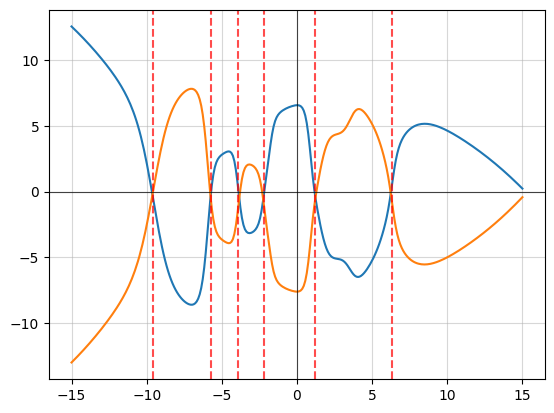

In [10]:
# logit visualizer

nn_classifier_mod = NeuralRegressor(
    input_dim=1, output_dim=2, hidden_layers=[], activation=classsify_activation_func)
nn_classifier_mod.model = classify_nn.model

y_morphed = nn_classifier_mod.predict(x_range)

plt.plot(x_range, y_morphed)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.axvline(0, color='black', linewidth=0.8, alpha=0.7)
for boundary in decision_boundaries[:-1]:
    plt.axvline(boundary, color='red', linestyle='--', alpha=0.7)
plt.grid(True, alpha=0.5)